In [18]:
import networkx as nx
import asymmetree.treeevolve as te
import matplotlib.pyplot as plt
import matplotlib.cm as cm

from asymmetree.visualization.tree_vis import visualize, assign_colors
from asymmetree.analysis import orthology_from_tree, bmg_from_tree
from tralda.datastructures.tree import TreeNode
from insert_Hybrid import insertHybrid

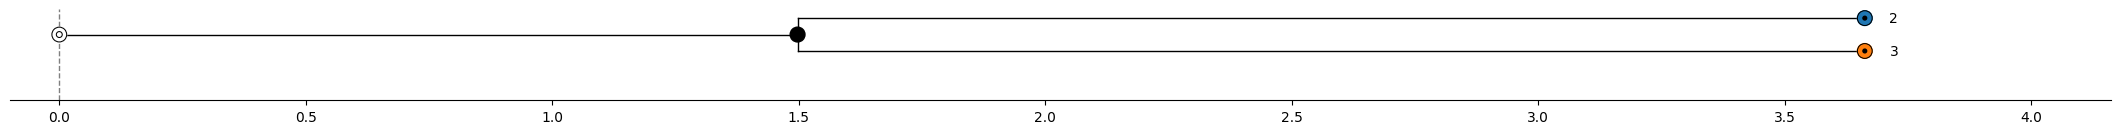

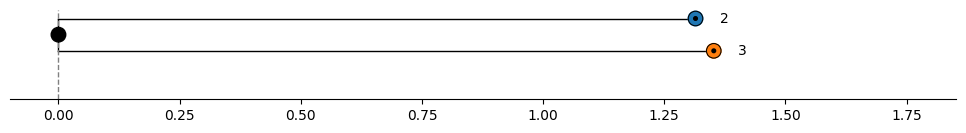

In [10]:
# Zufälligen Genbaum von Assymetree erstellen lassen.
# generate Species Tree

S = te.species_tree_n(n = 2)

# generate Gene Tree

dated_gene_tree = te.dated_gene_tree(
    S,
    dupl_rate=0.5,
    loss_rate=0.1,
    hgt_rate=0,
    dupl_polytomy=0.5
)

full_gene_tree = te.rate_heterogeneity(
    dated_gene_tree,
    S,
    base_rate=0.5,
    autocorr_variance=0.2,
)

# prune all loss branches and the planted root
pruned_gene_tree = te.prune_losses(full_gene_tree)

species_colors, gene_colors = assign_colors(S, dated_gene_tree)

visualize(S, color_dict=species_colors)

# visualize(dated_gene_tree, color_dict=gene_colors)
# visualize(full_gene_tree, color_dict=gene_colors)
visualize(pruned_gene_tree, color_dict=gene_colors)

In [19]:
G, root = pruned_gene_tree.to_nx()

insertHybrid(G)